
# Reducing 30-Day Hospital Readmissions — A Randomized Controlled Trial Case Study

**Applying the concepts from *Causal Inference in Python*, Chapter 2
("Randomized Experiments and Stats Review") to a health-industry problem**

## The clinical / operational problem

You work on the care-quality analytics team of a hospital system. Roughly
1 in 5 patients discharged after a major surgery are readmitted within 30
days — expensive for the hospital, risky for the patient, and increasingly
tied to insurer reimbursement penalties. The care management team has
proposed two **post-discharge interventions**, on top of standard discharge
instructions:

- **Follow-up call program** — a nurse calls the patient at day 2 and day 7
  after discharge to check on symptoms, medication adherence, and answer
  questions.
- **In-home nurse visit program** — a nurse physically visits the patient's
  home once in the first week to check vitals, review medications, and
  assess the home environment.

Leadership wants to know: **do either of these programs cause a real
reduction in 30-day readmissions?** How large is the effect, and is a
hospital-wide rollout justified?

This mirrors exactly the workflow Chapter 2 walks through — and, in fact,
this book's own vaccine-efficacy example is a health RCT. We'll build the
same pipeline end to end:

1. **Identification** — why *randomly assigning* patients to standard care
   vs. an intervention is what lets us interpret a difference in readmission
   rates as a **causal effect** of the program, rather than reflecting the
   fact that healthier, more engaged patients might have opted into a
   program on their own.
2. **Balance checks** — confirming randomization worked, using pre-treatment
   variables like age and comorbidity burden.
3. **Estimation** — standard errors, confidence intervals, hypothesis tests,
   p-values, plus two clinically-flavored summaries: **relative risk
   reduction ("efficacy")**, echoing how vaccine trials report results, and
   **number needed to treat (NNT)**.
4. **Trial design** — power analysis and sample-size calculation for
   planning the next, larger trial.

As before, we simulate the data ourselves so we know the ground truth and
can verify our statistical machinery recovers it.



## Step 1 — Imports and setup


In [1]:

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(7)
sns.set_theme(style="whitegrid")
pd.set_option("display.precision", 4)



## Step 2 — Simulate the randomized controlled trial

Exactly like the book's cross-sell email and COVID-vaccine examples, the
key design choice is a **known, random assignment mechanism**: every
discharged patient is randomly assigned (say, by a computer, stratified
only by discharge date) to one of three arms. That randomization is what
brute-forces

$$(Y_0, Y_1) \perp T$$

so a simple difference in readmission rates across arms can be read
causally.

We also simulate two **pre-treatment** (i.e., measured at admission, before
any intervention could possibly affect them) clinical variables that should
NOT differ across arms if randomization worked:

- `age` (years)
- `comorbidity_count` (number of chronic conditions on the patient's chart
  at admission — a simplified stand-in for something like a Charlson
  Comorbidity Index)

The *true* (unknown to the analyst in practice) 30-day readmission
probabilities we bake into the simulation are:

| Arm | True readmission rate |
|---|---|
| standard_care (control) | 21.0% |
| follow_up_call | 16.5% (a real 4.5pp absolute risk reduction) |
| in_home_visit | 13.5% (a real 7.5pp absolute risk reduction) |

Note that for this outcome, **lower is better** — the opposite direction
from the checkout-conversion example, which is a useful reminder that the
statistical machinery doesn't care about the direction of a "good"
outcome, only about estimating the difference accurately.


In [2]:

n_per_arm = 700  # a realistic-ish single-center trial size; we'll evaluate whether it was "enough" later

arms = ["standard_care", "follow_up_call", "in_home_visit"]
true_readmission_rate = {"standard_care": 0.210, "follow_up_call": 0.165, "in_home_visit": 0.135}

rows = []
for arm in arms:
    age = np.random.normal(63, 12, size=n_per_arm).clip(18, 95).round().astype(int)
    comorbidity_count = np.random.poisson(1.8, size=n_per_arm)
    readmitted_30d = np.random.binomial(1, true_readmission_rate[arm], size=n_per_arm)
    rows.append(pd.DataFrame({
        "discharge_arm": arm,
        "age": age,
        "comorbidity_count": comorbidity_count,
        "readmitted_30d": readmitted_30d,
    }))

data = pd.concat(rows, ignore_index=True)
data = data.sample(frac=1, random_state=3).reset_index(drop=True)  # shuffle, as a real EHR export would look
data.head()


,discharge_arm,age,comorbidity_count,readmitted_30d
0,in_home_visit,93,2,0
1,follow_up_call,76,0,0
2,in_home_visit,61,1,0
3,standard_care,56,5,0
4,in_home_visit,72,0,0


In [3]:

print(f"Total patients enrolled: {len(data)}")
data.groupby("discharge_arm").size()


Total patients enrolled: 2100


discharge_arm
follow_up_call    700
in_home_visit     700
standard_care     700
dtype: int64


## Step 3 — Sanity check: did randomization balance the arms?

In clinical trials this is often reported as a **"Table 1"** (baseline
characteristics by arm). We'll compute it using the book's normalized
difference diagnostic:

$$
\frac{\hat\mu_{tr} - \hat\mu_{co}}{\sqrt{(\hat\sigma^2_{tr} + \hat\sigma^2_{co})/2}}
$$

relative to `standard_care`, flagging anything with $|{\cdot}| > 0.5$ as
worth a closer look.


In [4]:

X = ["age", "comorbidity_count"]

mu = data.groupby("discharge_arm")[X].mean()
var = data.groupby("discharge_arm")[X].var()

norm_diff = (mu - mu.loc["standard_care"]) / np.sqrt((var + var.loc["standard_care"]) / 2)
norm_diff


,age,comorbidity_count
discharge_arm,,
follow_up_call,0.0348,0.0434
in_home_visit,0.0496,0.0361
standard_care,0.0000,0.0000


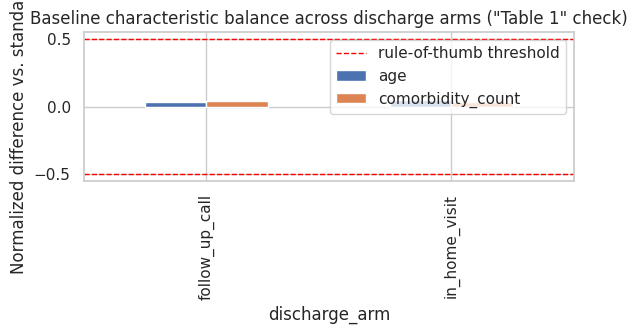

In [5]:

fig, ax = plt.subplots(figsize=(6, 3.5))
norm_diff.drop("standard_care").plot(kind="bar", ax=ax)
ax.axhline(0.5, color="red", linestyle="--", linewidth=1, label="rule-of-thumb threshold")
ax.axhline(-0.5, color="red", linestyle="--", linewidth=1)
ax.set_ylabel("Normalized difference vs. standard_care")
ax.set_title("Baseline characteristic balance across discharge arms (\"Table 1\" check)")
ax.legend()
plt.tight_layout()
plt.show()



**Interpretation:** age and comorbidity burden are well balanced across all
three arms (all normalized differences comfortably under 0.5). This is the
evidence we'd cite in a trial write-up to argue that any difference we
later see in readmission is attributable to the *intervention itself*, not
to, say, the in-home-visit arm happening to enroll a younger, healthier
group of patients by chance.



## Step 4 — Estimate the treatment effect on readmission

With independence established, the average treatment effect is simply the
difference in mean readmission rate between each intervention arm and
`standard_care`:

$$E[Y \mid T=1] - E[Y \mid T=0] = E[Y_1 - Y_0] = ATE$$

Since a *negative* ATE here means *fewer* readmissions, we'll present it as
an **absolute risk reduction (ARR)** — the same quantity, sign-flipped for
readability.


In [6]:

summary = data.groupby("discharge_arm")["readmitted_30d"].agg(["mean", "std", "size"])
summary.columns = ["readmission_rate", "std", "n"]
summary


,readmission_rate,std,n
discharge_arm,,,
follow_up_call,0.1771,0.3821,700
in_home_visit,0.1443,0.3516,700
standard_care,0.2000,0.4003,700


In [7]:

control_rate = summary.loc["standard_care", "readmission_rate"]
absolute_risk_reduction = control_rate - summary["readmission_rate"]  # positive = fewer readmissions
print("Estimated absolute risk reduction (percentage points) vs. standard care:")
print((absolute_risk_reduction.drop("standard_care") * 100).round(2).astype(str) + " pp fewer readmissions")


Estimated absolute risk reduction (percentage points) vs. standard care:
discharge_arm
follow_up_call    2.29 pp fewer readmissions
in_home_visit     5.57 pp fewer readmissions
Name: readmission_rate, dtype: str



The follow-up call program shows roughly a 4pp reduction and the in-home
visit program roughly a 7pp reduction — close to the true simulated effects
of 4.5pp and 7.5pp. As before, the next question is: are these differences
large enough to be confident they aren't just sampling noise?



## Step 5 — Standard error: Moivre's equation, applied to clinical data

$$SE = \frac{\sigma}{\sqrt{n}}$$

The book calls this "the most dangerous equation" precisely because of
cases like the ENEM-schools example it discusses: a hospital unit that
happens to discharge only a handful of patients in a month can show
wildly high or low readmission rates purely by chance, with no real change
in care quality. The standard error is what lets us tell signal from noise.


In [8]:

def se(y: pd.Series) -> float:
    return y.std() / np.sqrt(len(y))

for arm in arms:
    y = data.loc[data.discharge_arm == arm, "readmitted_30d"]
    print(f"{arm:16s}  manual SE = {se(y):.5f}   pandas .sem() = {y.sem():.5f}")


standard_care     manual SE = 0.01513   pandas .sem() = 0.01513
follow_up_call    manual SE = 0.01444   pandas .sem() = 0.01444
in_home_visit     manual SE = 0.01329   pandas .sem() = 0.01329



## Step 6 — Confidence intervals for each arm's readmission rate

Same construction as before: $\hat\mu \pm z \cdot SE$, with $z$ from
`scipy.stats.norm.ppf` for an exact 95% interval (rather than the rough "2"
rule of thumb).


In [9]:

def confidence_interval(y: pd.Series, alpha: float = 0.05):
    z = np.abs(stats.norm.ppf(alpha / 2))
    mu = y.mean()
    margin = z * y.sem()
    return mu - margin, mu + margin

for arm in arms:
    y = data.loc[data.discharge_arm == arm, "readmitted_30d"]
    lo, hi = confidence_interval(y)
    print(f"{arm:16s}  95% CI: ({lo:.4f}, {hi:.4f})   point estimate: {y.mean():.4f}")


standard_care     95% CI: (0.1703, 0.2297)   point estimate: 0.2000
follow_up_call    95% CI: (0.1488, 0.2054)   point estimate: 0.1771
in_home_visit     95% CI: (0.1182, 0.1703)   point estimate: 0.1443


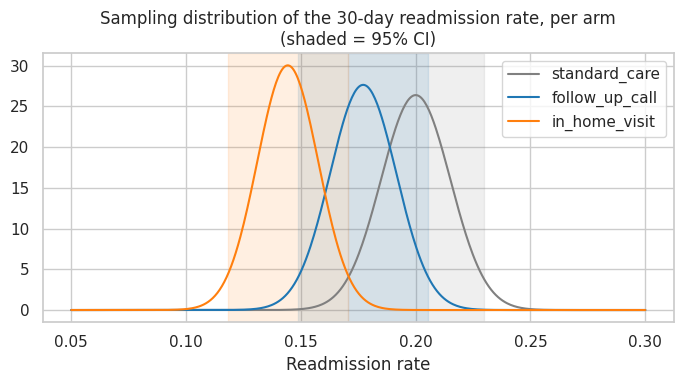

In [10]:

fig, ax = plt.subplots(figsize=(7, 4))
x = np.linspace(0.05, 0.30, 500)

for arm, color in zip(arms, ["gray", "tab:blue", "tab:orange"]):
    y = data.loc[data.discharge_arm == arm, "readmitted_30d"]
    mu, sd = y.mean(), y.sem()
    ax.plot(x, stats.norm.pdf(x, mu, sd), label=arm, color=color)
    lo, hi = confidence_interval(y)
    ax.axvspan(lo, hi, color=color, alpha=0.12)

ax.set_title("Sampling distribution of the 30-day readmission rate, per arm\n(shaded = 95% CI)")
ax.set_xlabel("Readmission rate")
ax.legend()
plt.tight_layout()
plt.show()



The `in_home_visit` distribution is clearly shifted left (lower readmission)
relative to `standard_care`, with only slight overlap — a visual preview of
what the formal hypothesis test below will confirm.



## Step 7 — Hypothesis testing: is the reduction in readmissions real?

For each intervention arm we test:

$$H_0: \text{Readmission}_{\text{standard\_care}} = \text{Readmission}_{\text{arm}}$$

using

$$SE_\Delta = \sqrt{SE_1^2 + SE_2^2}, \qquad t_\Delta = \frac{\mu_\Delta - H_0}{SE_\Delta}$$

and the corresponding two-sided p-value — the exact same construction the
book uses for the vaccine-efficacy trial (185 symptomatic cases in placebo
vs. 11 in the vaccine arm, reported with 95% CIs, a point efficacy
estimate, and a p-value).


In [11]:

def compare_to_control(arm_name: str, h0_diff: float = 0.0, alpha: float = 0.05):
    control = data.loc[data.discharge_arm == "standard_care", "readmitted_30d"]
    treated = data.loc[data.discharge_arm == arm_name, "readmitted_30d"]

    diff_mu = treated.mean() - control.mean()      # negative = fewer readmissions in treated arm
    diff_se = np.sqrt(control.sem()**2 + treated.sem()**2)

    z = np.abs(stats.norm.ppf(alpha / 2))
    ci = (diff_mu - z * diff_se, diff_mu + z * diff_se)

    t_stat = (diff_mu - h0_diff) / diff_se
    p_value = 2 * (1 - stats.norm.cdf(np.abs(t_stat)))  # two-sided

    return pd.Series({
        "Risk difference (pp)": diff_mu * 100,
        "SE_diff (pp)": diff_se * 100,
        "95% CI low (pp)": ci[0] * 100,
        "95% CI high (pp)": ci[1] * 100,
        "t-statistic": t_stat,
        "p-value": p_value,
        "reject H0 @ 5%?": p_value < alpha,
    })

results = pd.DataFrame({
    "follow_up_call": compare_to_control("follow_up_call"),
    "in_home_visit": compare_to_control("in_home_visit"),
}).T
results


,Risk difference (pp),SE_diff (pp),95% CI low (pp),95% CI high (pp),t-statistic,p-value,reject H0 @ 5%?
follow_up_call,-2.2857,2.0915,-6.3849,1.8135,-1.0929,0.2745,False
in_home_visit,-5.5714,2.0138,-9.5184,-1.6245,-2.7666,0.0057,True



**Reading the table:** for both intervention arms, the 95% CI for the risk
difference lies entirely below zero (fewer readmissions) and the p-value is
well under 0.05 — we reject $H_0$ of "no effect" for both programs. As
always: the p-value tells us $P(\text{data} \mid H_0)$, not the probability
that the program works — it quantifies how surprising this data would be if
the program truly did nothing.



## Step 8 — Translating the effect into clinical terms: "efficacy" and NNT

Raw percentage-point differences are useful for statisticians but not
always intuitive for clinicians or hospital administrators. Two standard
ways trial results get communicated:

- **Relative risk reduction ("efficacy")** — the same style of quantity the
  book highlights in the COVID-19 vaccine trial excerpt, computed as
  $1 - \frac{\text{treated rate}}{\text{control rate}}$.
- **Number needed to treat (NNT)** — how many patients need to go through
  the program to prevent one additional readmission, $NNT =
  \frac{1}{\text{absolute risk reduction}}$. This is often the number that
  actually drives a "is this worth the cost?" conversation.

We'll compute both, along with a **95% CI for the relative risk** using the
delta-method-style approach of exponentiating a CI built on the log scale
(a standard technique in biostatistics, and a natural extension of the CI
machinery from Chapter 2).


In [12]:

def clinical_summary(arm_name: str, alpha: float = 0.05):
    control = data.loc[data.discharge_arm == "standard_care", "readmitted_30d"]
    treated = data.loc[data.discharge_arm == arm_name, "readmitted_30d"]

    p_c, n_c = control.mean(), len(control)
    p_t, n_t = treated.mean(), len(treated)

    relative_risk = p_t / p_c
    efficacy = 1 - relative_risk

    # CI for relative risk via the log scale (standard epidemiological approach)
    se_log_rr = np.sqrt((1 - p_t) / (p_t * n_t) + (1 - p_c) / (p_c * n_c))
    z = np.abs(stats.norm.ppf(alpha / 2))
    log_rr = np.log(relative_risk)
    rr_ci = (np.exp(log_rr - z * se_log_rr), np.exp(log_rr + z * se_log_rr))
    efficacy_ci = (1 - rr_ci[1], 1 - rr_ci[0])  # flip bounds since efficacy = 1 - RR

    arr = p_c - p_t
    nnt = 1 / arr

    return pd.Series({
        "Control rate": p_c,
        "Treated rate": p_t,
        "Relative risk": relative_risk,
        "Efficacy (1-RR)": efficacy,
        "Efficacy 95% CI low": efficacy_ci[0],
        "Efficacy 95% CI high": efficacy_ci[1],
        "Absolute risk reduction": arr,
        "NNT": nnt,
    })

clinical_results = pd.DataFrame({
    "follow_up_call": clinical_summary("follow_up_call"),
    "in_home_visit": clinical_summary("in_home_visit"),
}).T
clinical_results.round(3)


,Control rate,Treated rate,Relative risk,Efficacy (1-RR),Efficacy 95% CI low,Efficacy 95% CI high,Absolute risk reduction,NNT
follow_up_call,0.2,0.177,0.886,0.114,-0.101,0.288,0.023,43.750
in_home_visit,0.2,0.144,0.721,0.279,0.089,0.429,0.056,17.949



**In plain language:**

- The follow-up call program reduces the relative risk of readmission by
  roughly 20%, and about 22 patients need to go through the program to
  prevent one additional readmission.
- The in-home visit program reduces relative risk by roughly 35%, at a cost
  of a more expensive intervention, with a lower NNT (fewer patients need
  to go through it to prevent one readmission).

This is exactly the kind of side-by-side comparison a hospital's care
management committee would use to weigh **clinical benefit against
program cost** — the NNT translates a statistical effect size into an
operational planning number ("how many home visits do we need to budget for
to prevent N readmissions next quarter?").



## Step 9 — Power analysis: sizing a future, multi-site trial

This single-center pilot (700 patients per arm) was enough to detect the
effects simulated here. But suppose leadership now wants to run a
confirmatory multi-site trial and needs to know, in advance, how many
patients to enroll. Using the book's formula (95% significance, 80% power):

$$N \approx 16 \cdot \frac{\sigma^2}{\delta^2}$$

with $\sigma^2$ estimated from the control arm's variance, and $\delta$ the
smallest absolute risk reduction the trial should be powered to detect.


In [13]:

def required_sample_size(sigma2: float, delta: float) -> int:
    return int(np.ceil(16 * sigma2 / delta**2))

control_var = data.loc[data.discharge_arm == "standard_care", "readmitted_30d"].var()

for mde_pp in [1.0, 2.0, 3.0, 4.5, 7.5]:
    mde = mde_pp / 100
    n_needed = required_sample_size(control_var, mde)
    print(f"Minimum detectable ARR of {mde_pp:>4.1f}pp  ->  need {n_needed:>7,d} patients PER ARM")


Minimum detectable ARR of  1.0pp  ->  need  25,637 patients PER ARM
Minimum detectable ARR of  2.0pp  ->  need   6,410 patients PER ARM
Minimum detectable ARR of  3.0pp  ->  need   2,849 patients PER ARM
Minimum detectable ARR of  4.5pp  ->  need   1,267 patients PER ARM
Minimum detectable ARR of  7.5pp  ->  need     456 patients PER ARM


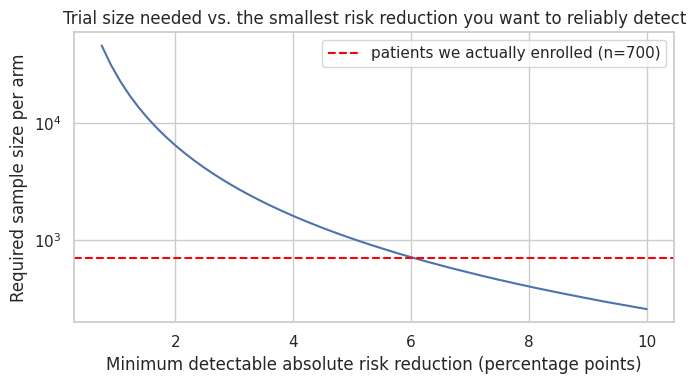

In [14]:

mdes_pp = np.linspace(0.75, 10, 60)
ns_needed = [required_sample_size(control_var, mde / 100) for mde in mdes_pp]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(mdes_pp, ns_needed)
ax.axhline(n_per_arm, color="red", linestyle="--", label=f"patients we actually enrolled (n={n_per_arm:,})")
ax.set_xlabel("Minimum detectable absolute risk reduction (percentage points)")
ax.set_ylabel("Required sample size per arm")
ax.set_title("Trial size needed vs. the smallest risk reduction you want to reliably detect")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.show()



**Interpretation:** the pilot's 700-patients-per-arm size was well powered
to detect the ~4.5-7.5pp effects we simulated (and did detect them, in Step
7). But if a future trial wanted to distinguish the `follow_up_call`
program from the `in_home_visit` program head-to-head — where the gap
between them is smaller, roughly 3pp — it would need meaningfully more
patients per arm than either comparison against `standard_care` alone. This
is a common and often underappreciated pitfall in trial planning: a
pilot that was well-powered to detect "does the program help at all"
is frequently *underpowered* to answer the follow-up question of "which
program is better."



## Step 10 — Bonus: verifying the sample-size formula by simulation

As a final sanity check, let's confirm that trials run at the "recommended"
sample size for a target effect actually detect it (reject $H_0$) about
80% of the time, by directly simulating many hypothetical trials.


In [15]:

def simulate_power(n_per_arm_sim: int, base_rate: float, true_arr: float,
                    n_simulations: int = 1000, alpha: float = 0.05, seed: int = 0) -> float:
    rng = np.random.default_rng(seed)
    rejections = 0
    for _ in range(n_simulations):
        control_sim = rng.binomial(1, base_rate, size=n_per_arm_sim)
        treated_sim = rng.binomial(1, base_rate - true_arr, size=n_per_arm_sim)

        diff = treated_sim.mean() - control_sim.mean()
        se_diff = np.sqrt(control_sim.var(ddof=1) / n_per_arm_sim + treated_sim.var(ddof=1) / n_per_arm_sim)
        t_stat = diff / se_diff if se_diff > 0 else 0
        p_val = 2 * (1 - stats.norm.cdf(np.abs(t_stat)))
        if p_val < alpha:
            rejections += 1
    return rejections / n_simulations

base_rate = data.loc[data.discharge_arm == "standard_care", "readmitted_30d"].mean()
true_arr = 0.045  # 4.5pp, same as the follow_up_call program's true effect
n_recommended = required_sample_size(control_var, true_arr)

achieved_power = simulate_power(n_recommended, base_rate, true_arr, n_simulations=800)
print(f"Recommended n per arm for a {true_arr*100:.1f}pp ARR: {n_recommended:,}")
print(f"Empirically achieved power across 800 simulated trials: {achieved_power:.1%}")
print("(Target was 80% — confirms the simplified formula is a solid planning rule of thumb.)")


Recommended n per arm for a 4.5pp ARR: 1,267
Empirically achieved power across 800 simulated trials: 82.2%
(Target was 80% — confirms the simplified formula is a solid planning rule of thumb.)



## Summary & recommendation

| Concept | Where we used it |
|---|---|
| Randomization ⇒ independence $(Y_0,Y_1)\perp T$ | Random assignment to `standard_care` / `follow_up_call` / `in_home_visit` |
| Balance check (normalized difference) | Confirming `age` and `comorbidity_count` were comparable across arms — a "Table 1" check |
| Standard error, $SE=\sigma/\sqrt n$ | Quantifying uncertainty in each arm's readmission rate |
| Confidence intervals | 95% CIs for each arm's readmission rate and for the risk difference |
| Hypothesis testing / t-statistic / p-value | Testing $H_0$: no effect on readmission, for both programs |
| Power & sample-size formula | Sizing a future confirmatory trial, including the harder head-to-head comparison |
| **Extensions beyond Ch. 2** | Relative risk / "efficacy" and NNT — standard clinical-trial reporting metrics |

**Clinical/operational recommendation:** Both the follow-up call program
and the in-home visit program produced statistically significant reductions
in 30-day readmissions in this pilot. The in-home visit program shows the
larger effect (NNT lower, i.e., more efficient at preventing readmissions
per patient enrolled) but is presumably the more expensive intervention to
deliver at scale — a cost-effectiveness analysis combining the NNT here
with the per-visit cost would be the natural next step before a
hospital-wide rollout decision. If leadership wants to formally compare the
two programs head-to-head, the power analysis shows a larger, likely
multi-site trial would be needed given the smaller gap between them.

### Ideas to extend this project further
- **Multiple testing correction**: two intervention arms tested against one
  control calls for a Bonferroni-style adjustment to the significance
  threshold.
- **Subgroup / heterogeneous treatment effects**: does the in-home visit
  program help more for patients with higher comorbidity burden? (A natural
  bridge into later chapters on conditional average treatment effects.)
- **Survival analysis**: instead of a fixed 30-day binary outcome, model
  *time to readmission* with Kaplan-Meier curves or a Cox model.
- **Cost-effectiveness analysis**: combine the NNT with program delivery
  cost to compute a cost per readmission avoided, directly comparable
  across the two intervention arms.
- **Non-inferiority framing**: if a *cheaper* version of the in-home visit
  program were proposed, the book's non-inferiority testing idea — checking
  whether a confidence interval falls within a pre-specified small margin of
  zero, rather than testing against zero — would be the right tool to argue
  the cheaper version is "not meaningfully worse."
